# Fictalent · Auditoria de qualidade · folha, o custo por cabeça
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar o que a Fictalent gasta com cada pessoa, competência a competência: os itens da folha por evento, as provisões de 13º, férias e encargos, os benefícios e o rateio que leva o custo de cada pessoa até o contrato onde ela trabalha. Sem o rateio existe custo total e não existe margem por cliente. A pergunta central é aritmética: a folha fecha consigo mesma e com o rateio?

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `folha`: `evento_folha`, `beneficio`, `folha_competencia`, `folha_item`, `provisao`, `colaborador_beneficio`, `rateio_custo`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. Os totais de cada competência batem com a soma dos itens, por tipo de evento?
2. O custo rateado por pessoa e mês bate com o que a folha pagou por ela, componente a componente, e o rateio aponta para a alocação certa?
3. A provisão encadeia mês a mês (saldo anterior mais valor do mês igual ao saldo acumulado)?
4. Há competência faltando, item para quem não tinha contrato, valor com sinal trocado?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude e coerência](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [A folha fecha consigo mesma](#secao-7)
8. [Competências e vigências](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("folha")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("folha")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

7 tabelas do domínio: evento_folha, beneficio, folha_competencia, folha_item, provisao, colaborador_beneficio, rateio_custo


## Nota Técnica

**Observado:** mesma configuração; as 7 tabelas do domínio lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 1.174.295


,tabela,linhas_vivas,marca
0,folha.evento_folha,24,2026-09-24 15:02:06.227515
1,folha.beneficio,2,2026-09-24 15:02:06.227515
2,folha.folha_competencia,246,2026-09-24 15:02:06.227515
3,folha.folha_item,932535,2026-09-24 15:02:06.227515
4,folha.provisao,146926,2026-09-24 15:02:06.227515
5,folha.colaborador_beneficio,31092,2026-09-24 15:02:06.227515
6,folha.rateio_custo,63470,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 1,17 milhão de linhas vivas: 932.535 itens de folha em 246 competências por filial, 146.926 provisões, 63.470 rateios, 31.092 benefícios concedidos, e os catálogos de 24 eventos e 4 benefícios.

**Por que importa:** sem o rateio existe custo total e não existe margem por cliente, que é a pergunta que ninguém sabe responder; este notebook confere se o rateio fecha com a folha antes de qualquer margem ser calculada.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

66 colunas em 7 tabelas
Colunas com um valor só: 4 (folha.evento_folha.criado_em, folha.evento_folha.atualizado_em, folha.beneficio.criado_em, folha.beneficio.atualizado_em)
Colunas totalmente vazias: 0


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,folha.evento_folha,id,BIGINT,0,0.00,24,1,24
1,folha.evento_folha,codigo,VARCHAR,0,0.00,26,ADIC_NOT,VT_EMP
2,folha.evento_folha,descricao,VARCHAR,0,0.00,24,13º proporcional na rescisão,"Vale-transporte, parte da empresa"
3,folha.evento_folha,tipo,VARCHAR,0,0.00,4,DESCONTO,PROVISAO
4,folha.evento_folha,fl_incide_inss,BOOLEAN,0,0.00,2,false,true
5,folha.evento_folha,fl_incide_fgts,BOOLEAN,0,0.00,2,false,true
6,folha.evento_folha,fl_incide_ir,BOOLEAN,0,0.00,2,false,true
7,folha.evento_folha,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
8,folha.evento_folha,atualizado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
9,folha.beneficio,id,BIGINT,0,0.00,2,1,2


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

66 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 66 colunas, tipos compatíveis com a DDL; só os carimbos dos dois catálogos são constantes; nenhuma coluna vazia.

**Por que importa:** o perfil aponta para a aritmética (seção 7), que é o assunto deste domínio.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude e coerência

Folha fechada tem data de fechamento; item de folha pertence a um contrato vigente na competência, da mesma pessoa e da mesma filial; provisão não é negativa; o rateio aponta para a alocação, o posto, o contrato e o centro de custo certos.

In [6]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 2; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
49,folha.colaborador_beneficio,vigencia_fim,DATE,1716,5.52,False
20,folha.folha_competencia,dt_fechamento,DATE,3,1.22,False


In [7]:
coerencia = consulta.sql(con, '''
    SELECT 'folha FECHADA sem dt_fechamento' AS caso, count(*) AS linhas FROM folha.folha_competencia WHERE excluido_em IS NULL AND status = 'FECHADA' AND dt_fechamento IS NULL
    UNION ALL SELECT 'folha ABERTA com dt_fechamento', count(*) FROM folha.folha_competencia WHERE excluido_em IS NULL AND status = 'ABERTA' AND dt_fechamento IS NOT NULL
    UNION ALL SELECT 'folha fechada antes do fim da competencia', count(*) FROM folha.folha_competencia WHERE excluido_em IS NULL AND dt_fechamento IS NOT NULL AND dt_fechamento < last_day(competencia)
    UNION ALL SELECT 'folha sem nenhum item', count(*) FROM folha.folha_competencia f WHERE f.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM folha.folha_item i WHERE i.excluido_em IS NULL AND i.folha_competencia_id = f.id)
    UNION ALL SELECT 'item de colaborador sem contrato vigente na competencia', count(*) FROM folha.folha_item i JOIN folha.folha_competencia f ON f.id = i.folha_competencia_id JOIN pessoas.contrato_trabalho k ON k.id = i.contrato_trabalho_id WHERE i.excluido_em IS NULL AND (k.dt_admissao > last_day(f.competencia) OR coalesce(k.dt_rescisao, DATE '9999-12-31') < f.competencia)
    UNION ALL SELECT 'item cujo contrato nao e do colaborador do item', count(*) FROM folha.folha_item i JOIN pessoas.contrato_trabalho k ON k.id = i.contrato_trabalho_id WHERE i.excluido_em IS NULL AND k.colaborador_id <> i.colaborador_id
    UNION ALL SELECT 'item cujo contrato e de outra filial que a folha', count(*) FROM folha.folha_item i JOIN folha.folha_competencia f ON f.id = i.folha_competencia_id JOIN pessoas.contrato_trabalho k ON k.id = i.contrato_trabalho_id WHERE i.excluido_em IS NULL AND k.filial_id <> f.filial_id
    UNION ALL SELECT 'provisao com saldo_acumulado < 0', count(*) FROM folha.provisao WHERE excluido_em IS NULL AND saldo_acumulado < 0
    UNION ALL SELECT 'colaborador_beneficio com valor <= 0', count(*) FROM folha.colaborador_beneficio WHERE excluido_em IS NULL AND valor <= 0
    UNION ALL SELECT 'rateio cujo custo_total <> soma das partes', count(*) FROM folha.rateio_custo WHERE excluido_em IS NULL AND abs(valor_salario + valor_encargos + valor_provisoes + valor_beneficios - custo_total) > 0.01
    UNION ALL SELECT 'rateio para alocacao que nao e do colaborador', count(*) FROM folha.rateio_custo r JOIN pessoas.alocacao a ON a.id = r.alocacao_id WHERE r.excluido_em IS NULL AND a.colaborador_id <> r.colaborador_id
    UNION ALL SELECT 'rateio para posto que nao e o da alocacao', count(*) FROM folha.rateio_custo r JOIN pessoas.alocacao a ON a.id = r.alocacao_id WHERE r.excluido_em IS NULL AND a.posto_id <> r.posto_id
    UNION ALL SELECT 'rateio para contrato que nao e o do posto', count(*) FROM folha.rateio_custo r JOIN comercial.posto p ON p.id = r.posto_id WHERE r.excluido_em IS NULL AND p.contrato_id <> r.contrato_id
    UNION ALL SELECT 'rateio para centro de custo que nao e o do contrato', count(*) FROM folha.rateio_custo r JOIN comercial.contrato k ON k.id = r.contrato_id WHERE r.excluido_em IS NULL AND k.centro_custo_id <> r.centro_custo_id
    UNION ALL SELECT 'rateio de alocacao nao vigente na competencia', count(*) FROM folha.rateio_custo r JOIN pessoas.alocacao a ON a.id = r.alocacao_id WHERE r.excluido_em IS NULL AND (a.dt_inicio > last_day(r.competencia) OR coalesce(a.dt_fim, DATE '9999-12-31') < r.competencia)
''')
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))
vazias = consulta.sql(con, "SELECT f.competencia, fl.codigo AS filial, f.status FROM folha.folha_competencia f JOIN cadastro.filial fl ON fl.id = f.filial_id WHERE f.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM folha.folha_item i WHERE i.excluido_em IS NULL AND i.folha_competencia_id = f.id) ORDER BY 1")
print(); print(vazias.to_string(index=False))
n_folhas = checagens.linhas(con, "folha.folha_competencia")
registro.anotar(
    secao="4", tabela="folha.folha_competencia", coluna="id (sem item)",
    achado="folhas sem item: os três primeiros meses das filiais recém-abertas e as folhas abertas do mês corrente (regra, não defeito)", linhas=0, total=n_folhas, severidade="nenhuma",
    impacto="nenhum: filial sem admitidos não tem item", acao="nenhuma",
)

Testes de coerência: 15; com linhas: 1
                                                   caso  linhas
                        folha FECHADA sem dt_fechamento       0
                         folha ABERTA com dt_fechamento       0
              folha fechada antes do fim da competencia       0
                                  folha sem nenhum item       9
item de colaborador sem contrato vigente na competencia       0
        item cujo contrato nao e do colaborador do item       0
       item cujo contrato e de outra filial que a folha       0
                       provisao com saldo_acumulado < 0       0
                   colaborador_beneficio com valor <= 0       0
             rateio cujo custo_total <> soma das partes       0
          rateio para alocacao que nao e do colaborador       0
              rateio para posto que nao e o da alocacao       0
              rateio para contrato que nao e o do posto       0
    rateio para centro de custo que nao e o do contrato       0
 


competencia filial  status
 2019-03-01    BRG FECHADA
 2019-04-01    BRG FECHADA
 2019-05-01    BRG FECHADA
 2022-08-01    EXT FECHADA
 2022-09-01    EXT FECHADA
 2022-10-01    EXT FECHADA
 2026-09-01    ATB  ABERTA
 2026-09-01    EXT  ABERTA
 2026-09-01    BRG  ABERTA


Achado(dominio='folha', secao='4', tabela='folha.folha_competencia', coluna='id (sem item)', achado='folhas sem item: os três primeiros meses das filiais recém-abertas e as folhas abertas do mês corrente (regra, não defeito)', linhas=0, total=246, severidade='nenhuma', impacto='nenhum: filial sem admitidos não tem item', acao='nenhuma', declaracao='')

## Nota Técnica

**Observado:** duas colunas com nulo, ambas por regra: a data de fechamento das três folhas abertas de setembro de 2026 e a vigência aberta de 1.716 benefícios em vigor. Dos 15 testes de coerência, 14 passaram: folha fechada sempre com data, item sempre de contrato vigente na competência, da mesma pessoa e da mesma filial, provisão nunca negativa, rateio sempre com a soma das partes, para a alocação, o posto, o contrato e o centro de custo certos e vigentes. Nove folhas não têm item: os três primeiros meses de Bragança Paulista (2019) e de Extrema (2022), filiais recém-abertas sem admitidos, e as três folhas abertas do mês corrente.

**Por que importa:** a coerência do rateio com alocação, posto, contrato e centro de custo é o que garante que o custo chega ao cliente certo; passou inteira.

**Ação:** nenhuma. Registrar as folhas vazias como regra, não defeito.

<a id="secao-5"></a>

# 5. Unicidade

Competência por filial, provisão por competência, pessoa e tipo, e as chaves de conteúdo: o mesmo item duas vezes na mesma folha, o mesmo rateio duas vezes, dois benefícios iguais vigentes ao mesmo tempo.

In [8]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
for tabela, colunas, descricao in (
    ("folha.folha_item", ["folha_competencia_id", "colaborador_id", "contrato_trabalho_id", "evento_id"], "o mesmo evento duas vezes para a pessoa na mesma folha"),
    ("folha.rateio_custo", ["competencia", "colaborador_id", "alocacao_id"], "o mesmo rateio duas vezes"),
    ("folha.colaborador_beneficio", ["colaborador_id", "beneficio_id", "vigencia_inicio"], "o mesmo beneficio concedido duas vezes no mesmo dia"),
):
    grupos, envolvidas = checagens.repetidos(con, tabela, colunas)
    print(f"{tabela:<30} {'+'.join(colunas):<70} {grupos:>5} grupos  {envolvidas:>6} linhas   ({descricao})")
print(f"colaborador_beneficio: vigências cruzadas do mesmo benefício na mesma pessoa: {checagens.sobreposicoes(con, 'folha.colaborador_beneficio', ['colaborador_id', 'beneficio_id'], 'vigencia_inicio', 'vigencia_fim')}")

4 chaves UNIQUE conferidas; com repetição: 0
                 tabela                             chave  grupos_repetidos  linhas
     folha.evento_folha                            codigo                 0       0
        folha.beneficio                            codigo                 0       0
folha.folha_competencia            competencia, filial_id                 0       0
         folha.provisao competencia, colaborador_id, tipo                 0       0
folha.folha_item               folha_competencia_id+colaborador_id+contrato_trabalho_id+evento_id         0 grupos       0 linhas   (o mesmo evento duas vezes para a pessoa na mesma folha)
folha.rateio_custo             competencia+colaborador_id+alocacao_id                                     0 grupos       0 linhas   (o mesmo rateio duas vezes)
folha.colaborador_beneficio    colaborador_id+beneficio_id+vigencia_inicio                                0 grupos       0 linhas   (o mesmo beneficio concedido duas vezes no mesmo dia)


## Nota Técnica

**Observado:** as 4 chaves `UNIQUE` íntegras; nenhum item, rateio ou benefício duplicado por conteúdo; nenhum benefício com vigências cruzadas na mesma pessoa.

**Por que importa:** cada pessoa-mês tem uma folha, um rateio e um benefício de cada tipo.

**Ação:** nenhuma.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK` e a distribuição: quais eventos existem e quanto pesam.

In [9]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
eventos = consulta.sql(con, '''
    SELECT e.tipo, e.codigo, e.descricao, count(i.id) AS itens, round(sum(i.valor), 2) AS soma, count(*) FILTER (WHERE i.valor < 0) AS negativos, count(*) FILTER (WHERE i.valor = 0) AS zerados
    FROM folha.evento_folha e LEFT JOIN folha.folha_item i ON i.evento_id = e.id AND i.excluido_em IS NULL WHERE e.excluido_em IS NULL GROUP BY 1, 2, 3 ORDER BY 1, 2''')
print(eventos.to_string(index=False))

4 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,folha.evento_folha,tipo,4,0,
1,folha.beneficio,tipo,4,0,
2,folha.folha_competencia,status,3,0,
3,folha.provisao,tipo,3,0,


    tipo    codigo                                     descricao  itens          soma  negativos  zerados
DESCONTO   ATRASOS      Desconto de atrasos e saídas antecipadas  30305    382,385.54          0        0
DESCONTO    FALTAS                            Desconto de faltas  17217  1,342,849.22          0        0
DESCONTO      INSS                             INSS do empregado  63463  7,952,286.59          0        0
DESCONTO      IRRF                       Imposto de renda retido   1442     36,076.25          0        0
DESCONTO   VR_DESC                     Desconto de vale-refeição  62969  2,624,716.06          0        0
DESCONTO   VT_DESC                   Desconto de vale-transporte  62969  5,532,032.71          0        0
 ENCARGO      FGTS                                          FGTS  63463  7,769,276.27          0        0
 ENCARGO  INSS_PAT                                 INSS patronal  63463 19,423,193.79          0        0
 ENCARGO       RAT                            

## Nota Técnica

**Observado:** os 4 domínios só têm valores previstos. Os 24 eventos estão todos em uso: 9 proventos (salário em 63.470 itens; horas extras, adicionais, 13º e verbas rescisórias), 6 descontos, 6 encargos (INSS patronal, FGTS, RAT, terceiros e a parte da empresa nos vales) e 3 provisões. Nenhum item negativo ou zerado.

**Por que importa:** a lista de eventos é a gramática da folha; saber que todos existem e nenhum tem sinal trocado permite compor o custo por pessoa a partir dos itens.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. A folha fecha consigo mesma

Os totais da competência contra a soma dos itens por tipo; a provisão encadeada mês a mês; e o rateio contra a folha da mesma pessoa e mês, componente a componente (salário com os proventos mensais, encargos com encargos, benefícios com a parte da empresa, provisões com provisões).

In [10]:
totais = consulta.sql(con, '''
    WITH soma AS (
      SELECT i.folha_competencia_id,
             sum(i.valor) FILTER (WHERE e.tipo = 'PROVENTO') AS proventos, sum(i.valor) FILTER (WHERE e.tipo = 'DESCONTO') AS descontos, sum(i.valor) FILTER (WHERE e.tipo = 'ENCARGO') AS encargos
      FROM folha.folha_item i JOIN folha.evento_folha e ON e.id = i.evento_id WHERE i.excluido_em IS NULL GROUP BY 1)
    SELECT count(*) AS folhas,
           count(*) FILTER (WHERE abs(f.total_proventos - coalesce(s.proventos, 0)) > 0.01) AS proventos_nao_batem,
           count(*) FILTER (WHERE abs(f.total_descontos - coalesce(s.descontos, 0)) > 0.01) AS descontos_nao_batem,
           count(*) FILTER (WHERE abs(f.total_encargos - coalesce(s.encargos, 0)) > 0.01) AS encargos_nao_batem
    FROM folha.folha_competencia f LEFT JOIN soma s ON s.folha_competencia_id = f.id WHERE f.excluido_em IS NULL''')
print(totais.to_string(index=False))
registro.anotar(
    secao="7", tabela="folha.folha_competencia", coluna="total_proventos, total_descontos, total_encargos",
    achado="hipótese refutada: os totais de cada competência batem com a soma dos itens em todas as folhas", linhas=int(totais.iloc[0, 1:].sum()), total=int(totais.iloc[0]["folhas"]), severidade="nenhuma",
    impacto="a folha fecha consigo mesma", acao="nenhuma",
)

 folhas  proventos_nao_batem  descontos_nao_batem  encargos_nao_batem
    246                    0                    0                   0


Achado(dominio='folha', secao='7', tabela='folha.folha_competencia', coluna='total_proventos, total_descontos, total_encargos', achado='hipótese refutada: os totais de cada competência batem com a soma dos itens em todas as folhas', linhas=0, total=246, severidade='nenhuma', impacto='a folha fecha consigo mesma', acao='nenhuma', declaracao='')

In [11]:
provisao = consulta.sql(con, '''
    WITH p AS (
      SELECT colaborador_id, tipo, competencia, valor_mes, saldo_acumulado,
             lag(saldo_acumulado) OVER (PARTITION BY colaborador_id, tipo ORDER BY competencia) AS saldo_anterior
      FROM folha.provisao WHERE excluido_em IS NULL)
    SELECT count(*) AS linhas, count(*) FILTER (WHERE saldo_anterior IS NULL) AS primeiras,
           count(*) FILTER (WHERE saldo_anterior IS NOT NULL AND abs(saldo_anterior + valor_mes - saldo_acumulado) <= 0.01) AS encadeadas,
           count(*) FILTER (WHERE saldo_anterior IS NOT NULL AND abs(saldo_anterior + valor_mes - saldo_acumulado) > 0.01) AS fora_do_encadeamento,
           count(*) FILTER (WHERE valor_mes < 0) AS baixas_no_mes
    FROM p''')
print(provisao.to_string(index=False))
fora = consulta.sql(con, '''
    WITH p AS (SELECT colaborador_id, tipo, competencia, valor_mes, saldo_acumulado, lag(saldo_acumulado) OVER (PARTITION BY colaborador_id, tipo ORDER BY competencia) AS saldo_anterior FROM folha.provisao WHERE excluido_em IS NULL)
    SELECT colaborador_id, tipo, competencia, saldo_anterior, valor_mes, saldo_acumulado FROM p WHERE saldo_anterior IS NOT NULL AND abs(saldo_anterior + valor_mes - saldo_acumulado) > 0.01 ORDER BY 1, 2, 3''')
display(fora)
registro.anotar(
    secao="7", tabela="folha.provisao", coluna="saldo_acumulado, valor_mes",
    achado="provisão fora do encadeamento: saldo zerado sem baixa registrada, ou saldo reiniciado", linhas=int(provisao.iloc[0]["fora_do_encadeamento"]), total=int(provisao.iloc[0]["linhas"]), severidade="baixa",
    impacto="a provisão dessas pessoas não é reconstruível mês a mês", acao="marcar na silver; o cliente explica a baixa",
)

 linhas  primeiras  encadeadas  fora_do_encadeamento  baixas_no_mes
 146926      35013      111904                     9          32626


,colaborador_id,tipo,competencia,saldo_anterior,valor_mes,saldo_acumulado
0,4298,DECIMO_TERCEIRO,2023-08-01,133.76,0.00,0.00
1,4298,ENCARGOS,2023-08-01,111.73,0.00,0.00
2,4298,FERIAS,2023-08-01,178.34,0.00,0.00
3,7025,DECIMO_TERCEIRO,2025-04-01,170.68,214.28,214.28
4,7025,ENCARGOS,2025-04-01,142.58,179.00,179.00
5,7025,FERIAS,2025-04-01,227.58,285.71,285.71
6,7748,DECIMO_TERCEIRO,2024-10-01,378.67,169.81,169.81
7,7748,ENCARGOS,2024-10-01,316.32,141.85,141.85
8,7748,FERIAS,2024-10-01,504.90,226.41,226.41


Achado(dominio='folha', secao='7', tabela='folha.provisao', coluna='saldo_acumulado, valor_mes', achado='provisão fora do encadeamento: saldo zerado sem baixa registrada, ou saldo reiniciado', linhas=9, total=146926, severidade='baixa', impacto='a provisão dessas pessoas não é reconstruível mês a mês', acao='marcar na silver; o cliente explica a baixa', declaracao='')

In [12]:
rateio_folha = consulta.sql(con, '''
    WITH pago AS (
      SELECT f.competencia, i.colaborador_id,
             sum(i.valor) FILTER (WHERE e.tipo = 'PROVENTO' AND e.codigo NOT IN ('RESC_13', 'RESC_FER', 'DEC_TERC')) AS proventos_mensais,
             sum(i.valor) FILTER (WHERE e.codigo IN ('FGTS', 'INSS_PAT', 'RAT', 'TERCEIROS')) AS encargos,
             sum(i.valor) FILTER (WHERE e.codigo IN ('VR_EMP', 'VT_EMP')) AS beneficios,
             sum(i.valor) FILTER (WHERE e.tipo = 'PROVISAO') AS provisoes
      FROM folha.folha_item i JOIN folha.folha_competencia f ON f.id = i.folha_competencia_id JOIN folha.evento_folha e ON e.id = i.evento_id
      WHERE i.excluido_em IS NULL GROUP BY 1, 2),
    rateado AS (
      SELECT competencia, colaborador_id, sum(valor_salario) AS salario, sum(valor_encargos) AS encargos, sum(valor_provisoes) AS provisoes, sum(valor_beneficios) AS beneficios
      FROM folha.rateio_custo WHERE excluido_em IS NULL GROUP BY 1, 2)
    SELECT count(*) AS pessoa_mes_na_folha, count(r.competencia) AS com_rateio,
           count(*) FILTER (WHERE abs(r.salario - p.proventos_mensais) > 0.01) AS salario_rateado_diferente,
           count(*) FILTER (WHERE abs(r.encargos - coalesce(p.encargos, 0)) > 0.01) AS encargo_diferente,
           count(*) FILTER (WHERE abs(r.beneficios - coalesce(p.beneficios, 0)) > 0.01) AS beneficio_diferente,
           count(*) FILTER (WHERE abs(r.provisoes - coalesce(p.provisoes, 0)) > 0.01) AS provisao_diferente,
           round(sum(p.proventos_mensais), 0) AS proventos_mensais_pagos, round(sum(r.salario), 0) AS salario_rateado,
           round(100.0 * (sum(r.salario) - sum(p.proventos_mensais)) / sum(p.proventos_mensais), 2) AS diferenca_pct
    FROM pago p LEFT JOIN rateado r ON r.competencia = p.competencia AND r.colaborador_id = p.colaborador_id''')
print(rateio_folha.to_string(index=False))
razoes = consulta.sql(con, '''
    WITH pago AS (SELECT f.competencia, i.colaborador_id, sum(i.valor) FILTER (WHERE e.tipo = 'PROVENTO' AND e.codigo NOT IN ('RESC_13', 'RESC_FER', 'DEC_TERC')) AS mensais FROM folha.folha_item i JOIN folha.folha_competencia f ON f.id = i.folha_competencia_id JOIN folha.evento_folha e ON e.id = i.evento_id WHERE i.excluido_em IS NULL GROUP BY 1, 2),
    rateado AS (SELECT competencia, colaborador_id, sum(valor_salario) AS salario FROM folha.rateio_custo WHERE excluido_em IS NULL GROUP BY 1, 2)
    SELECT round(r.salario / p.mensais, 2) AS razao_rateado_sobre_pago, count(*) AS pessoa_mes FROM pago p JOIN rateado r USING (competencia, colaborador_id) WHERE abs(r.salario - p.mensais) > 0.01 GROUP BY 1 ORDER BY 2 DESC LIMIT 6''')
print(razoes.to_string(index=False))
zerados = checagens.contar(con, "SELECT count(*) FROM folha.rateio_custo WHERE excluido_em IS NULL AND custo_total <= 0")
n_rateios = checagens.linhas(con, "folha.rateio_custo")
registro.anotar(
    secao="7", tabela="folha.rateio_custo", coluna="valor_salario",
    achado="salário rateado diferente dos proventos mensais pagos na folha da mesma pessoa e mês (sempre um pouco abaixo; 1,7% a menos no agregado)", linhas=int(rateio_folha.iloc[0]["salario_rateado_diferente"]), total=int(rateio_folha.iloc[0]["pessoa_mes_na_folha"]), severidade="media",
    impacto="o rateio é a base da margem por cliente; salário rateado menor que o pago faz a margem de cada contrato parecer maior do que é, sem que o total da folha acuse",
    acao="o catálogo pede ao cliente a regra do rateio; a silver marca a diferença por pessoa-mês e não corrige",
)
registro.anotar(
    secao="7", tabela="folha.rateio_custo", coluna="custo_total",
    achado="rateio com custo zero", linhas=zerados, total=n_rateios, severidade="baixa",
    impacto="alocação no mês sem custo atribuído ao contrato", acao="marcar; o cliente confere",
)
print(f"anotados: {len(registro)}")

 pessoa_mes_na_folha  com_rateio  salario_rateado_diferente  encargo_diferente  beneficio_diferente  provisao_diferente  proventos_mensais_pagos  salario_rateado  diferenca_pct
               63445       63445                      39104                  0                    0                   0            98,841,201.00    97,115,966.00          -1.75


 razao_rateado_sobre_pago  pessoa_mes
                     0.99       10981
                     1.00        7625
                     0.97        7155
                     0.96        3911
                     0.98        2432
                     0.93        1895
anotados: 5


## Nota Técnica

**Observado:** **A folha fecha consigo mesma:** os totais de proventos, descontos e encargos das 246 competências batem com a soma dos itens em todas, sem uma diferença de centavo. A provisão encadeia (saldo anterior mais valor do mês igual ao saldo acumulado) em 111.904 das 146.926 linhas e é primeira linha em 35.013; sobram 9 linhas de 3 pessoas fora do encadeamento (um saldo zerado sem baixa registrada e dois saldos reiniciados). **O rateio não fecha com a folha no salário:** todo pessoa-mês da folha tem rateio (63.445, nenhum sem), encargos batem em 63.438, benefícios e provisões em 100%, mas o salário rateado difere dos proventos mensais da folha em 39.104 pessoa-mês (61,6%), sempre um pouco abaixo (razão típica de 0,99 a 0,97), e no agregado o rateio soma R$ 97,1 milhões contra R$ 98,8 milhões de proventos mensais pagos, 1,7% a menos. Sete rateios têm custo zero.

**Por que importa:** o rateio é a base da margem por cliente; se o salário rateado é 1,7% menor que o pago, a margem de cada contrato aparece 1,7% maior do que é, e ninguém vê porque a folha total está certa. A diferença sistemática e pequena sugere uma regra de rateio (proporção de dias alocados, por exemplo) que não considera algum provento, e isso precisa ser dito pelo cliente, não adivinhado.

**Ação:** anotar o rateio × folha como achado de severidade média: o catálogo pede ao cliente a regra do rateio; a silver não corrige e marca a diferença por pessoa-mês; os 7 rateios zerados e as 9 provisões fora do encadeamento entram como baixa.

<a id="secao-8"></a>

# 8. Competências e vigências

Toda competência é o primeiro dia do mês; cada filial tem uma folha por mês desde a abertura, sem buraco; benefício com vigência coerente.

In [13]:
competencias = consulta.sql(con, '''
    SELECT 'competencia que nao e dia 1' AS caso, count(*) AS linhas FROM folha.folha_competencia WHERE excluido_em IS NULL AND day(competencia) <> 1
    UNION ALL SELECT 'provisao com competencia que nao e dia 1', count(*) FROM folha.provisao WHERE excluido_em IS NULL AND day(competencia) <> 1
    UNION ALL SELECT 'rateio com competencia que nao e dia 1', count(*) FROM folha.rateio_custo WHERE excluido_em IS NULL AND day(competencia) <> 1
    UNION ALL SELECT 'beneficio com vigencia_fim antes do inicio', count(*) FROM folha.colaborador_beneficio WHERE excluido_em IS NULL AND vigencia_fim < vigencia_inicio
    UNION ALL SELECT 'beneficio comecando antes da admissao', count(*) FROM folha.colaborador_beneficio b JOIN pessoas.colaborador p ON p.id = b.colaborador_id WHERE b.excluido_em IS NULL AND b.vigencia_inicio < p.dt_admissao_primeira
    UNION ALL SELECT 'folha de competencia futura', count(*) FROM folha.folha_competencia WHERE excluido_em IS NULL AND competencia > ?
''', HOJE)
print(competencias.to_string(index=False))
buracos = consulta.sql(con, '''
    WITH arco AS (SELECT filial_id, min(competencia) AS primeira, max(competencia) AS ultima, count(*) AS folhas FROM folha.folha_competencia WHERE excluido_em IS NULL GROUP BY 1)
    SELECT f.codigo AS filial, a.primeira, a.ultima, a.folhas, date_diff('month', a.primeira, a.ultima) + 1 AS meses_esperados
    FROM arco a JOIN cadastro.filial f ON f.id = a.filial_id ORDER BY 1''')
print(buracos.to_string(index=False))

                                      caso  linhas
               competencia que nao e dia 1       0
  provisao com competencia que nao e dia 1       0
    rateio com competencia que nao e dia 1       0
beneficio com vigencia_fim antes do inicio       0
     beneficio comecando antes da admissao       0
               folha de competencia futura       0
filial   primeira     ultima  folhas  meses_esperados
   ATB 2018-01-01 2026-09-01     105              105
   BRG 2019-03-01 2026-09-01      91               91
   EXT 2022-08-01 2026-09-01      50               50


## Nota Técnica

**Observado:** toda competência é o primeiro dia do mês, nenhuma folha futura, nenhum benefício com fim antes do início ou antes da admissão, e cada filial tem uma folha por mês desde a abertura sem buraco: Atibaia 105 meses, Bragança 91, Extrema 50.

**Por que importa:** série mensal completa por filial é o que permite o consolidado (auditado no financeiro) ser comparado mês a mês.

**Ação:** nenhuma.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL; o rateio aponta para cinco tabelas de três módulos.

In [14]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

13 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,folha.folha_competencia,filial_id,cadastro.filial,0
1,folha.folha_item,folha_competencia_id,folha.folha_competencia,0
2,folha.folha_item,colaborador_id,pessoas.colaborador,0
3,folha.folha_item,contrato_trabalho_id,pessoas.contrato_trabalho,0
4,folha.folha_item,evento_id,folha.evento_folha,0
5,folha.provisao,colaborador_id,pessoas.colaborador,0
6,folha.colaborador_beneficio,colaborador_id,pessoas.colaborador,0
7,folha.colaborador_beneficio,beneficio_id,folha.beneficio,0
8,folha.rateio_custo,colaborador_id,pessoas.colaborador,0
9,folha.rateio_custo,alocacao_id,pessoas.alocacao,0


## Nota Técnica

**Observado:** as 13 chaves estrangeiras sem órfão; o rateio aponta para cinco tabelas de três módulos e todas respondem.

**Por que importa:** junções seguras.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. Regras do domínio

O sinal de cada tipo de evento, o salário contra o contrato, e o retrato do custo ano a ano.

In [15]:
regras = consulta.sql(con, '''
    SELECT 'item PROVENTO com valor < 0' AS caso, count(*) AS linhas FROM folha.folha_item i JOIN folha.evento_folha e ON e.id = i.evento_id WHERE i.excluido_em IS NULL AND e.tipo = 'PROVENTO' AND i.valor < 0
    UNION ALL SELECT 'item DESCONTO com valor < 0', count(*) FROM folha.folha_item i JOIN folha.evento_folha e ON e.id = i.evento_id WHERE i.excluido_em IS NULL AND e.tipo = 'DESCONTO' AND i.valor < 0
    UNION ALL SELECT 'item com valor = 0', count(*) FROM folha.folha_item WHERE excluido_em IS NULL AND valor = 0
    UNION ALL SELECT 'pessoa-mes sem evento de salario', count(*) FROM (SELECT DISTINCT i.folha_competencia_id, i.colaborador_id FROM folha.folha_item i WHERE i.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM folha.folha_item s JOIN folha.evento_folha e ON e.id = s.evento_id WHERE s.excluido_em IS NULL AND s.folha_competencia_id = i.folha_competencia_id AND s.colaborador_id = i.colaborador_id AND e.codigo = 'SALARIO'))
    UNION ALL SELECT 'salario da folha maior que 2x o salario_base do contrato', count(*) FROM folha.folha_item i JOIN folha.evento_folha e ON e.id = i.evento_id JOIN pessoas.contrato_trabalho k ON k.id = i.contrato_trabalho_id WHERE i.excluido_em IS NULL AND e.codigo = 'SALARIO' AND i.valor > 2 * k.salario_base
    UNION ALL SELECT 'rateio com custo_total <= 0', count(*) FROM folha.rateio_custo WHERE excluido_em IS NULL AND custo_total <= 0
''')
print(regras.to_string(index=False))

                                                    caso  linhas
                             item PROVENTO com valor < 0       0
                             item DESCONTO com valor < 0       0
                                      item com valor = 0       0
                        pessoa-mes sem evento de salario       0
salario da folha maior que 2x o salario_base do contrato       0
                             rateio com custo_total <= 0       7


In [16]:
retrato = consulta.sql(con, '''
    SELECT year(f.competencia) AS ano, count(DISTINCT f.id) AS folhas, count(DISTINCT i.colaborador_id) AS pessoas, round(sum(i.valor) FILTER (WHERE e.tipo = 'PROVENTO'), 0) AS proventos
    FROM folha.folha_competencia f JOIN folha.folha_item i ON i.folha_competencia_id = f.id AND i.excluido_em IS NULL JOIN folha.evento_folha e ON e.id = i.evento_id WHERE f.excluido_em IS NULL GROUP BY 1 ORDER BY 1''')
print(retrato.to_string(index=False))
print(consulta.sql(con, "SELECT year(competencia) AS ano, round(sum(custo_total), 0) AS custo_rateado, count(DISTINCT contrato_id) AS contratos FROM folha.rateio_custo WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1").to_string(index=False))

 ano  folhas  pessoas     proventos
2018      12      310  1,766,964.00
2019      19      789  3,792,298.00
2020      24      656  3,329,392.00
2021      24     1012  4,505,864.00
2022      26     1963  9,390,793.00
2023      36     3024 15,943,400.00
2024      36     4431 24,922,029.00
2025      36     4014 30,290,771.00
2026      24     2774 18,797,149.00
 ano  custo_rateado  contratos
2018   2,923,338.00          9
2019   6,143,521.00         14
2020   5,347,243.00         18
2021   7,437,983.00         20
2022  15,451,852.00         31
2023  26,357,808.00         45
2024  40,924,828.00         62
2025  49,609,122.00         57
2026  29,382,429.00         52


## Nota Técnica

**Observado:** as 6 regras passaram: nenhum provento ou desconto negativo, nenhum item zerado, toda pessoa-mês tem salário, nenhum salário acima do dobro do salário-base do contrato; os 7 rateios zerados já anotados. O retrato: a folha cresce de 310 pessoas em 2018 para 4.431 em 2024, e o custo rateado de R$ 2,9 milhões para R$ 49,6 milhões em 2025.

**Por que importa:** o retrato é a escala do problema da margem: 1,7% de R$ 49,6 milhões são R$ 840 mil por ano atribuídos ao cliente errado ou a nenhum.

**Ação:** nenhuma além do já anotado.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [17]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        0
     media        1
     baixa        2
   nenhuma        2

Total: 5 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,media,7,folha.rateio_custo,valor_salario,salário rateado diferente dos proventos mensais pagos na folha da mesma pessoa e mês (sempre um ...,39104,63445,61.63,
1,baixa,7,folha.provisao,"saldo_acumulado, valor_mes","provisão fora do encadeamento: saldo zerado sem baixa registrada, ou saldo reiniciado",9,146926,0.01,
2,baixa,7,folha.rateio_custo,custo_total,rateio com custo zero,7,63470,0.01,
3,nenhuma,4,folha.folha_competencia,id (sem item),folhas sem item: os três primeiros meses das filiais recém-abertas e as folhas abertas do mês co...,0,246,0.00,
4,nenhuma,7,folha.folha_competencia,"total_proventos, total_descontos, total_encargos",hipótese refutada: os totais de cada competência batem com a soma dos itens em todas as folhas,0,246,0.00,


In [18]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,media,folha.rateio_custo,valor_salario,o rateio é a base da margem por cliente; salário rateado menor que o pago faz a margem de cada c...,o catálogo pede ao cliente a regra do rateio; a silver marca a diferença por pessoa-mês e não co...
1,baixa,folha.provisao,"saldo_acumulado, valor_mes",a provisão dessas pessoas não é reconstruível mês a mês,marcar na silver; o cliente explica a baixa
2,baixa,folha.rateio_custo,custo_total,alocação no mês sem custo atribuído ao contrato,marcar; o cliente confere
3,nenhuma,folha.folha_competencia,id (sem item),nenhum: filial sem admitidos não tem item,nenhuma
4,nenhuma,folha.folha_competencia,"total_proventos, total_descontos, total_encargos",a folha fecha consigo mesma,nenhuma


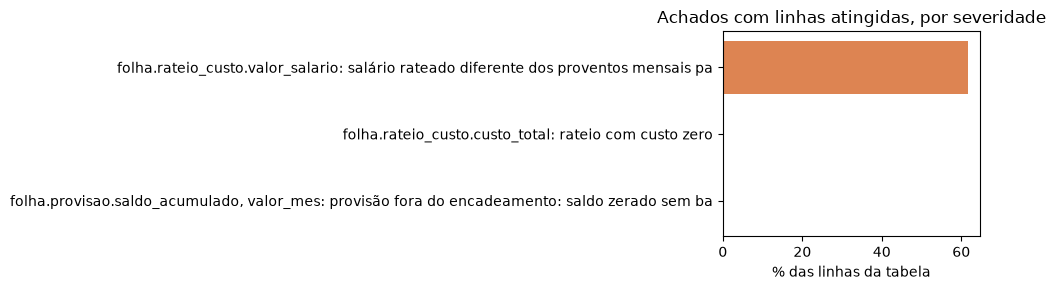

registro gravado em dados/auditoria/folha.json


In [19]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 7 tabelas do domínio `folha`, 66 colunas e 1,17 milhão de linhas vivas, na carga identificada na seção 2: tipo, completude e coerência, unicidade, domínios, a aritmética da folha (totais, rateio e provisão), competências e vigências, integridade referencial e regras.

**O veredicto: a folha fecha consigo mesma e o rateio não fecha com a folha.** Totais, encargos, benefícios, provisões, competências e referências passaram inteiros. O achado que importa é um só e é de margem: o salário rateado fica 1,7% abaixo do pago em 61,6% dos pessoa-mês (média), o que faz toda margem por cliente parecer maior do que é. Em volta dele, sete rateios zerados e nove provisões fora do encadeamento (baixas). Dois registros de severidade nenhuma: os totais batem em 100% e as folhas vazias são de filial recém-aberta.

**Próximos passos:** `financeiro`, onde o custo rateado encontra a receita faturada e o consolidado da gerência.